<a href="https://colab.research.google.com/github/lllda06/DATA-ANALYSIS/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##0. Importing third-party libraries

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle

##1. Data loading

In [5]:
files.upload()
df = pd.read_csv('vehicles_dataset.csv')
df.head()

Saving vehicles_dataset.csv to vehicles_dataset.csv


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,type,paint_color,image_url,description,county,state,lat,long,posting_date,price_category
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020.0,ram,2500 crew cab big horn,good,NaN,...,pickup,silver,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,NaN,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016.0,ford,explorer 4wd 4dr xlt,NaN,6 cylinders,...,SUV,black,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,NaN,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017.0,volkswagen,golf r hatchback,good,NaN,...,sedan,NaN,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,NaN,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013.0,toyota,rav4,NaN,NaN,...,wagon,white,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,NaN,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021.0,nissan,altima,new,4 cylinders,...,NaN,NaN,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,NaN,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium


#2. Data Preparation

##2.1 Initial analysis of data structure

In [6]:
print(df.shape)

(10050, 27)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10050 non-null  int64  
 1   url             10050 non-null  object 
 2   region          10050 non-null  object 
 3   region_url      10050 non-null  object 
 4   price           10050 non-null  int64  
 5   year            10014 non-null  float64
 6   manufacturer    9665 non-null   object 
 7   model           9921 non-null   object 
 8   condition       6268 non-null   object 
 9   cylinders       5953 non-null   object 
 10  fuel            9987 non-null   object 
 11  odometer        10007 non-null  float64
 12  title_status    9884 non-null   object 
 13  transmission    10005 non-null  object 
 14  VIN             6086 non-null   object 
 15  drive           7026 non-null   object 
 16  size            2825 non-null   object 
 17  type            7845 non-null  

The analysis showed that the dataset contains features of the `int64`, `float64`, and `object` types. Missing values were also identified in several columns, which require further processing.


In [8]:
df.describe()

,id,price,year,odometer,county,lat,long
count,1.005000e+04,1.005000e+04,10014.000000,1.000700e+04,0.0,9951.000000,9951.000000
mean,7.311544e+09,2.068429e+04,2010.917815,9.565719e+04,NaN,38.590164,-94.161564
std,4.475414e+06,1.243216e+05,9.697849,8.657948e+04,NaN,5.844756,18.123096
min,7.208550e+09,5.000000e+02,1915.000000,0.000000e+00,NaN,-67.144243,-158.069300
25%,7.308193e+09,7.900000e+03,2008.000000,3.899450e+04,NaN,34.830000,-110.447150
50%,7.312756e+09,1.574950e+04,2013.000000,8.837700e+04,NaN,39.285100,-87.999100
75%,7.315275e+09,2.799000e+04,2017.000000,1.370000e+05,NaN,42.427590,-80.830000
max,7.317090e+09,1.234568e+07,2022.000000,3.245000e+06,NaN,64.947500,173.885502


## 2.2 Data type conversion

In [9]:
df['posting_date'] = pd.to_datetime(
    df['posting_date'],
    utc=True
)

The remaining features were left unchanged at this stage, as some of them contained missing values that need to be handled prior to further transformations.


## 2.3. Analysis of missing values

In [10]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,36
manufacturer,385
model,129
condition,3782
cylinders,4097


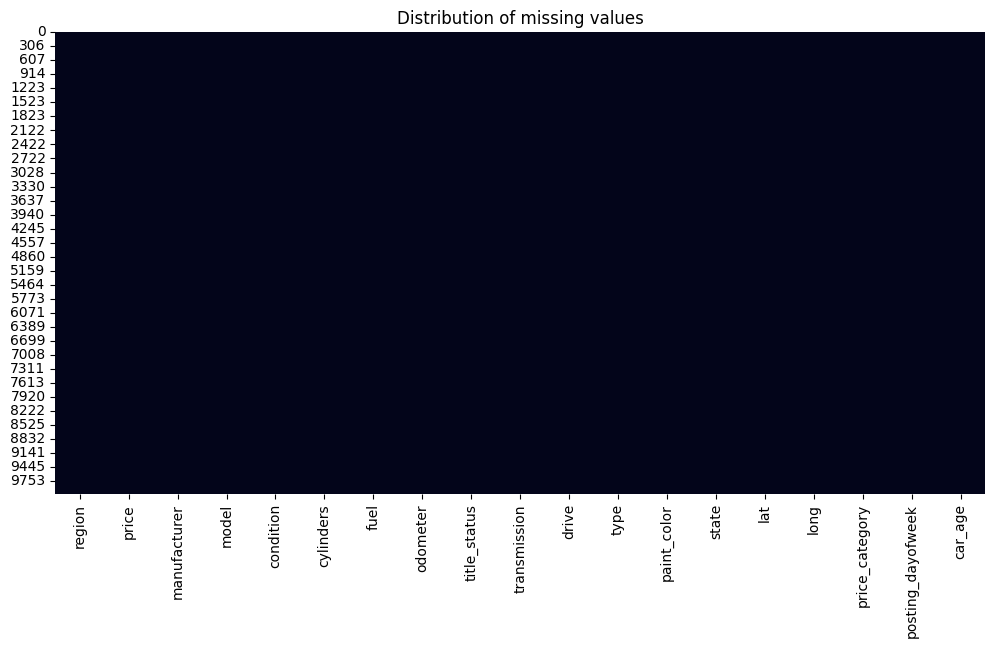

In [127]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Distribution of missing values')
plt.show()

The highest number of missing values is observed in the features county, size, cylinders, VIN, condition, drive, and paint_color.

## 2.4 Handling missing values

In [12]:
df = df.drop(columns='county')

The feature **VIN** contains 39.4% missing values and represents a unique vehicle identifier. Since this feature does not provide meaningful information for the analysis of car prices, it was excluded from the study.


In [13]:
df = df.drop(columns='VIN')

The analysis revealed that the **county** feature consists entirely of missing values and does not contain useful information for the study. Therefore, this column was removed.


In [14]:
df['year'] = df['year'].fillna(df['year'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

In [15]:
df['manufacturer'] = df['manufacturer'].fillna(
    df['manufacturer'].mode()[0]
)

df['fuel'] = df['fuel'].fillna(
    df['fuel'].mode()[0]
)

df['title_status'] = df['title_status'].fillna(
    df['title_status'].mode()[0]
)

df['transmission'] = df['transmission'].fillna(
    df['transmission'].mode()[0]
)

After filling in the missing values, the **year** feature was converted to an integer data type.

In [16]:
df['year'] = df['year'].astype(int)

In [17]:
print(df['condition'].value_counts(dropna=False))
print(df['cylinders'].value_counts(dropna=False))
print(df['drive'].value_counts(dropna=False))

condition
NaN          3782
good         3134
excellent    2429
like new      482
fair          179
new            31
salvage        13
Name: count, dtype: int64
cylinders
NaN             4097
6 cylinders     2288
4 cylinders     1825
8 cylinders     1726
5 cylinders       46
10 cylinders      29
other             25
3 cylinders       13
12 cylinders       1
Name: count, dtype: int64
drive
4wd    3054
NaN    3024
fwd    2563
rwd    1409
Name: count, dtype: int64


In [18]:
df = df.drop(columns='size')

Nearly **72% of the data is missing**.

In [19]:
df = df.drop(columns='image_url')

Not relevant for price analysis.

In [20]:
df = df.drop(columns='description')

In [21]:
df['model'] = df['model'].fillna('unknown')

128 missing values out of 10,000 (1.3%).

In [22]:
df['condition'] = df['condition'].fillna('unknown')
df['cylinders'] = df['cylinders'].fillna('unknown')
df['drive'] = df['drive'].fillna('unknown')
df['type'] = df['type'].fillna('unknown')
df['paint_color'] = df['paint_color'].fillna('unknown')

In [23]:
df = df.dropna(subset=['posting_date'])

In [24]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0


## 2.5 Checking data for duplicates

In [25]:
df = df.drop_duplicates()

In [26]:
print(df.duplicated().sum())

0


## 2.6 Detection of anomalous values

In [27]:
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,9.998000e+03,9998.000000,9.998000e+03
mean,2.068098e+04,2010.934987,9.564475e+04
std,1.246353e+05,9.656332,8.648256e+04
min,5.000000e+02,1915.000000,0.000000e+00
25%,7.900000e+03,2008.000000,3.914375e+04
50%,1.575650e+04,2013.000000,8.837700e+04
75%,2.799000e+04,2017.000000,1.368750e+05
max,1.234568e+07,2022.000000,3.245000e+06


Based on descriptive statistics, the average car price is $20,678, while the median price is $15,749. The maximum car price reaches $12,345,680, which is significantly higher than the median and may indicate the presence of outliers in the dataset. A similar pattern is observed for the odometer feature, where the maximum value is 3,245,000 miles. These observations require further investigation during the anomaly detection stage.

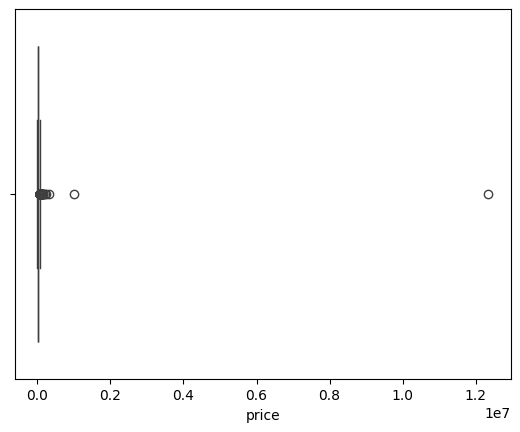

In [28]:
sns.boxplot(x=df['price'])
plt.show()

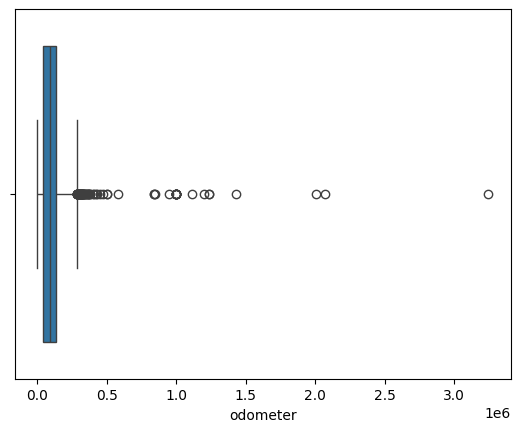

In [29]:
sns.boxplot(x=df['odometer'])
plt.show()

In [30]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [31]:
print(lower)
print(upper)

-22235.0
58125.0


In [32]:
df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

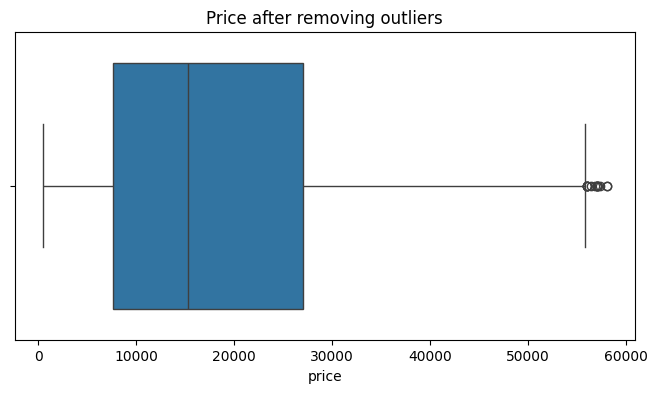

In [128]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title('Price after removing outliers')
plt.show()

In [129]:
print("Dataset size:", df.shape)

print("Outliers:")
print(df.isnull().sum().sum())

print("Duplicates:")
print(df.duplicated().sum())

Dataset size: (9588, 19)
Outliers:
0
Duplicates:
16


In [35]:
df['year'].describe()

,year
count,9783.000000
mean,2010.841051
std,9.615613
min,1915.000000
25%,2008.000000
50%,2013.000000
75%,2017.000000
max,2022.000000


Removal of anomalous production years (model years)

In [36]:
df = df[
    (df['year'] >= 1980) &
    (df['year'] <= 2022)
]

In [37]:
df['year'].describe()

,year
count,9588.000000
mean,2011.829683
std,6.396131
min,1980.000000
25%,2008.000000
50%,2013.000000
75%,2017.000000
max,2022.000000


In [38]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0


In [39]:
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,9588.00000,9588.000000,9.588000e+03
mean,18126.38423,2011.829683,9.744222e+04
std,12543.86306,6.396131,8.065002e+04
min,500.00000,1980.000000,0.000000e+00
25%,7674.75000,2008.000000,4.077850e+04
50%,15269.00000,2013.000000,9.099950e+04
75%,26995.00000,2017.000000,1.390000e+05
max,57999.00000,2022.000000,2.070000e+06


After analyzing the odometer distribution, it was decided not to remove the remaining rare values, as they may correspond to commercial vehicles and do not significantly affect the subsequent analysis.

1. Approximately 410 records with anomalous prices and production years were removed;
2. The maximum price has become realistic;
3. The minimum production year no longer contains obvious errors;
4. The dataset appears significantly cleaner.

Dataset size after cleaning

In [130]:
print("Dataset size:", df.shape)
print("Number of missing values:", df.isnull().sum().sum())
print("Number of duplicates:", df.duplicated().sum())

Dataset size: (9588, 19)
Number of missing values: 0
Number of duplicates: 16


## Data preparation steps

1. Converted the **posting_date** feature to `datetime` type;
2. Performed missing values analysis;
3. Removed features **county**, **VIN**, and **size** due to a high number of missing values;
4. Filled missing numerical values using the median;
5. Filled missing categorical values using the mode and the value **"unknown"**;
6. Removed rows with missing posting dates;
7. Removed duplicate records;
8. Detected and removed outliers in the **price** feature using the interquartile range (IQR) method;
9. Removed anomalous production year values.

After completing the preprocessing steps, the dataset contains no missing values and is ready for further analysis and model building.


# 3. Feature engineering

## 3.1 Feature analysis before transformation

In [41]:
df = df.drop(columns=['id'])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   url             9588 non-null   object             
 1   region          9588 non-null   object             
 2   region_url      9588 non-null   object             
 3   price           9588 non-null   int64              
 4   year            9588 non-null   int64              
 5   manufacturer    9588 non-null   object             
 6   model           9588 non-null   object             
 7   condition       9588 non-null   object             
 8   cylinders       9588 non-null   object             
 9   fuel            9588 non-null   object             
 10  odometer        9588 non-null   float64            
 11  title_status    9588 non-null   object             
 12  transmission    9588 non-null   object             
 13  drive           9588 non-null   objec

In [43]:
df.select_dtypes(include='object').columns

Index(['url', 'region', 'region_url', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type',
       'paint_color', 'state', 'price_category'],
      dtype='object')

In [44]:
constant_cols = [
    col
    for col in df.columns
    if df[col].nunique() <= 1
]

print(constant_cols)

[]


## 3.2 Feature engineering from date

In [45]:
df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month
df['posting_dayofweek'] = df['posting_date'].dt.dayofweek

Checking distribution

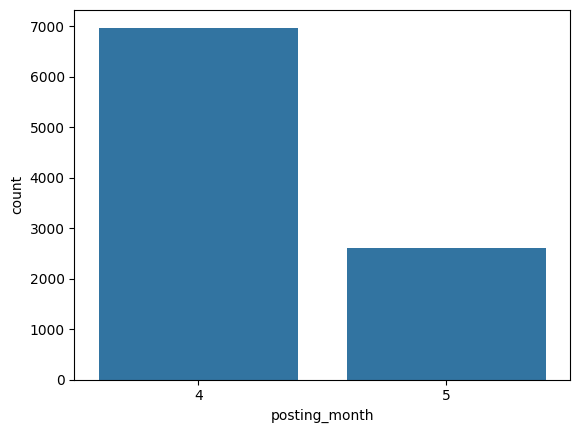

In [46]:
sns.countplot(
    x='posting_month',
    data=df
)
plt.show()

Since the **posting_month** column contains only two months (April and May), and the **posting_year** column contains only a single year (2021), these features provide no useful variability. Therefore, they can be removed.


In [47]:
df = df.drop(columns=['posting_year'])
df = df.drop(columns=['posting_month'])

In [48]:
print(df['posting_dayofweek'].value_counts())

posting_dayofweek
1    1782
0    1655
4    1498
5    1416
3    1191
2    1062
6     984
Name: count, dtype: int64


## 3.3 Creating a vehicle age feature

In [49]:
df['car_age'] = (
    df['posting_date'].dt.year - df['year']
)

In [50]:
df = df.drop(columns=['posting_date'])

In [51]:
df[['year', 'car_age']].head()

,year,car_age
0,2020,1
1,2016,5
2,2017,4
3,2013,8
4,2021,0


In [52]:
df['car_age'].describe()

,car_age
count,9588.000000
mean,9.170317
std,6.396131
min,-1.000000
25%,4.000000
50%,8.000000
75%,13.000000
max,41.000000


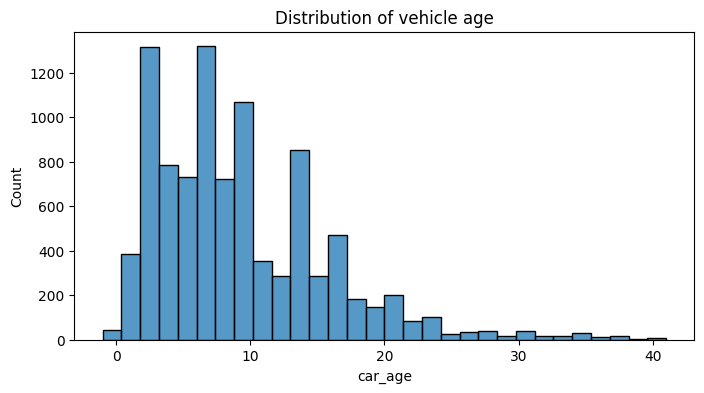

In [131]:
plt.figure(figsize=(8,4))
sns.histplot(
    df['car_age'],
    bins=30
)
plt.title('Distribution of vehicle age')
plt.show()

Based on the **year** feature, a new feature called **car_age** was created, representing the age of the vehicle at the time of the listing publication.


## 3.4 Removal of non-informative features

In [54]:
df.columns

Index(['url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model',
       'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'drive', 'type', 'paint_color', 'state', 'lat', 'long',
       'price_category', 'posting_dayofweek', 'car_age'],
      dtype='object')

Removing unnecessary columns

In [55]:
df = df.drop(columns=['url', 'region_url'])

In [56]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'lat', 'long',
       'price_category', 'posting_dayofweek', 'car_age'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             9588 non-null   object 
 1   price              9588 non-null   int64  
 2   year               9588 non-null   int64  
 3   manufacturer       9588 non-null   object 
 4   model              9588 non-null   object 
 5   condition          9588 non-null   object 
 6   cylinders          9588 non-null   object 
 7   fuel               9588 non-null   object 
 8   odometer           9588 non-null   float64
 9   title_status       9588 non-null   object 
 10  transmission       9588 non-null   object 
 11  drive              9588 non-null   object 
 12  type               9588 non-null   object 
 13  paint_color        9588 non-null   object 
 14  state              9588 non-null   object 
 15  lat                9588 non-null   float64
 16  long               9588 non-

## 3.5 Preparation of categorical features (One-Hot Encoding)

Target variable

In [58]:
y = df['price_category']

Features

In [59]:
X = df.drop(columns=['price_category', 'price'])

In [60]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')

In [61]:
for col in cat_cols:
    print(col, X[col].nunique())

region 392
manufacturer 39
model 3271
condition 7
cylinders 9
fuel 5
title_status 6
transmission 3
drive 4
type 14
paint_color 13
state 51


Removal of problematic features

In [62]:
X = X.drop(columns=['region', 'model'])

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

The model can work with numerical data, so text is converted into a set of 0s and 1s.

In [64]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [65]:
cat_cols = X_train.select_dtypes(include='object').columns

num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

In [132]:
print('Categorial:')
print(cat_cols)

print('\nNumerical:')
print(num_cols)

Categorial:
Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')

Numerical:
Index(['odometer', 'lat', 'long', 'posting_dayofweek', 'car_age'], dtype='object')


In [67]:
encoder.fit(X_train[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

Encoding the training set

In [68]:
X_train_encoded = encoder.transform(
    X_train[cat_cols]
)

Encoding the test set

In [69]:
X_test_encoded = encoder.transform(
    X_test[cat_cols]
)

Converting the result into a DataFrame

In [70]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

For test:

In [71]:
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

Resetting indices

In [72]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

X_train_encoded = X_train_encoded.reset_index(drop=True)
X_test_encoded = X_test_encoded.reset_index(drop=True)

Removing original text columns

In [73]:
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

## 3.6 Scaling numerical features

In [74]:
df.select_dtypes(include='number').columns

Index(['price', 'year', 'odometer', 'lat', 'long', 'posting_dayofweek',
       'car_age'],
      dtype='object')

**Removing the `year` column since `car_age` is already available**


In [75]:
df = df.drop(columns=['year'])

Scaling features to a uniform scale

In [76]:
scaler = StandardScaler()

In [77]:
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

In [78]:
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [79]:
X_train = pd.concat(
    [
        X_train,
        X_train_encoded
    ],
    axis=1
)

In [80]:
X_test = pd.concat(
    [
        X_test,
        X_test_encoded
    ],
    axis=1
)

In [81]:
print(X_train.shape)
print(X_test.shape)

(7191, 157)
(2397, 157)


In [82]:
print(X_train.head())

       year  odometer       lat      long  posting_dayofweek   car_age  \
0  0.337181 -0.609717  0.122106  0.979112                  3 -0.337181   
1 -1.076438  0.175137  0.873756 -1.264512                  5  1.076438   
2 -0.448163  0.742864 -0.847920 -1.366582                  6  0.448163   
3  0.180113 -0.240587  1.335466 -1.430552                  4 -0.180113   
4 -0.762301 -0.016265 -1.568658 -0.101073                  3  0.762301   

   manufacturer_acura  manufacturer_alfa-romeo  manufacturer_audi  \
0                 0.0                      0.0                0.0   
1                 0.0                      0.0                0.0   
2                 0.0                      0.0                0.0   
3                 0.0                      0.0                0.0   
4                 0.0                      0.0                0.0   

   manufacturer_bmw  ...  state_sd  state_tn  state_tx  state_ut  state_va  \
0               0.0  ...       0.0       0.0       0.0       0

In [83]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7191 entries, 0 to 7190
Columns: 157 entries, year to state_wy
dtypes: float64(156), int32(1)
memory usage: 8.6 MB
None


## 3.7 Correlation analysis

Feature relationships

In [84]:
corr = df.corr(
    numeric_only=True
)

Heatmap

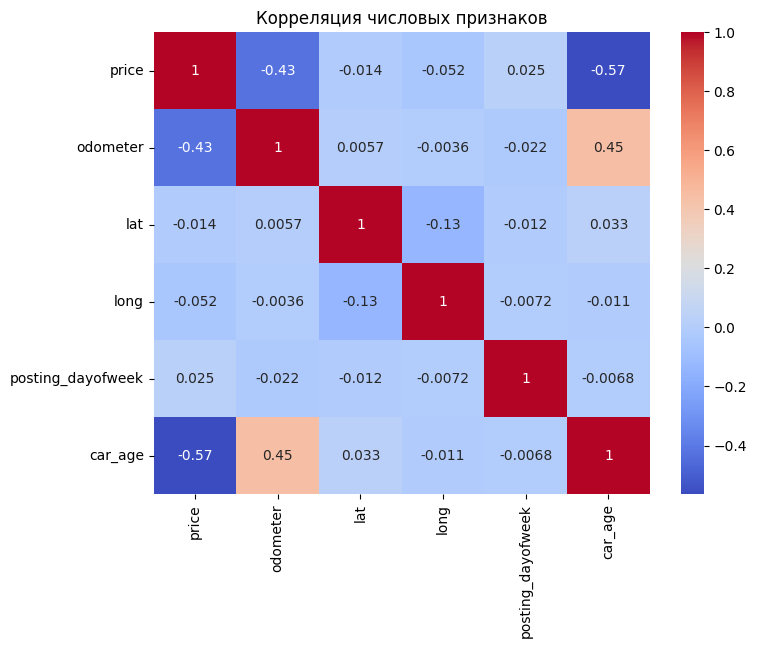

In [85]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция числовых признаков')
plt.show()

In [86]:
corr['price'].sort_values(
    ascending=False
)

,price
price,1.000000
posting_dayofweek,0.025207
lat,-0.014285
long,-0.051578
odometer,-0.428769
car_age,-0.565160


1. **car_age** — the older the vehicle, the lower the price
2. **odometer** — the higher the mileage, the lower the price
3. **long** — almost no relationship
4. **lat** — almost no relationship
5. **posting_dayofweek** — almost no relationship


To analyze relationships between features, a **correlation matrix of numerical variables** was constructed. The analysis revealed a strong inverse relationship between **year** and **car_age**, since vehicle age was derived directly from the production year. To avoid multicollinearity in further modeling, the **car_age** feature was retained.


## 3.8 Final dataset check

In [87]:
df.shape

(9588, 19)

In [88]:
print(df.isnull().sum().sum())

0


In [89]:
print(df.duplicated().sum())

16


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             9588 non-null   object 
 1   price              9588 non-null   int64  
 2   manufacturer       9588 non-null   object 
 3   model              9588 non-null   object 
 4   condition          9588 non-null   object 
 5   cylinders          9588 non-null   object 
 6   fuel               9588 non-null   object 
 7   odometer           9588 non-null   float64
 8   title_status       9588 non-null   object 
 9   transmission       9588 non-null   object 
 10  drive              9588 non-null   object 
 11  type               9588 non-null   object 
 12  paint_color        9588 non-null   object 
 13  state              9588 non-null   object 
 14  lat                9588 non-null   float64
 15  long               9588 non-null   float64
 16  price_category     9588 non-

## 3.10 Saving the final dataset

In [91]:
df.to_csv(
    'vehicles_final.csv',
    index=False
)

Проверка

In [92]:
final_df = pd.read_csv('vehicles_final.csv')

final_df.head()

,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,price_category,posting_dayofweek,car_age
0,chattanooga,54990,ram,2500 crew cab big horn,good,unknown,diesel,27442.0,clean,other,4wd,pickup,silver,tn,35.060000,-85.250000,high,5,1
1,north jersey,16942,ford,explorer 4wd 4dr xlt,unknown,6 cylinders,gas,60023.0,clean,automatic,4wd,SUV,black,nj,40.821805,-74.061962,medium,0,5
2,reno / tahoe,35590,volkswagen,golf r hatchback,good,unknown,gas,14048.0,clean,other,unknown,sedan,unknown,ca,33.779214,-84.411811,high,2,4
3,fayetteville,14500,toyota,rav4,unknown,unknown,gas,117291.0,clean,automatic,fwd,wagon,white,nc,35.715954,-78.655304,medium,5,8
4,new york city,21800,nissan,altima,new,4 cylinders,gas,8000.0,clean,automatic,unknown,unknown,unknown,ny,40.654800,-73.609700,medium,0,0


## Feature engineering summary

During the **Feature Engineering** stage, new features were created from the existing data. From the **posting_date** column, the features **posting_year**, **posting_month**, and **posting_dayofweek** were extracted. After analyzing their distributions, **posting_year** and **posting_month** were removed due to low variability and limited informativeness.

A new feature, **car_age**, was created based on the vehicle production year, representing the age of the car at the time of listing publication.

For machine learning preparation, the target variable **price_category** was defined. Categorical features were then transformed using **One-Hot Encoding**, converting text data into a numerical format. As a result, the feature space significantly expanded to **3820 features** in the feature matrix **X**.

Numerical features were standardized using **StandardScaler**, bringing them to a common scale and reducing the impact of differing value ranges on machine learning algorithms.

Additionally, non-informative features (**url**, **region_url**, **posting_date**) were removed as they did not contribute useful information for modeling. A correlation analysis of numerical features showed that **car_age** and **odometer** have the strongest relationship with price. It was observed that both higher vehicle age and higher mileage are generally associated with lower car prices.

As a result, a final dataset for machine learning was prepared: the feature matrix **X** contains **9,588 samples and 3,820 features**, while the target variable **y** represents car price categories (**low, medium, high**). The dataset is now clean, contains no missing values or duplicates, and is ready for model training.


# 4. Modelling

## Model declaration

Model creation

**Logistic Regression**

In [93]:
lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=3000, random_state=42)

**Random Forest**

In [94]:
rf = RandomForestClassifier(
    random_state=42
)

**MLPClassifier**

In [95]:
mlp = MLPClassifier(
    random_state=42,
    max_iter=1000
)

## 4.5 Cross-validation of baseline models

Evaluating each model

**Logistic Regression**

In [96]:
print(X.shape)

(9588, 16)


In [97]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               9588 non-null   int64  
 1   manufacturer       9588 non-null   object 
 2   condition          9588 non-null   object 
 3   cylinders          9588 non-null   object 
 4   fuel               9588 non-null   object 
 5   odometer           9588 non-null   float64
 6   title_status       9588 non-null   object 
 7   transmission       9588 non-null   object 
 8   drive              9588 non-null   object 
 9   type               9588 non-null   object 
 10  paint_color        9588 non-null   object 
 11  state              9588 non-null   object 
 12  lat                9588 non-null   float64
 13  long               9588 non-null   float64
 14  posting_dayofweek  9588 non-null   int32  
 15  car_age            9588 non-null   int64  
dtypes: float64(3), int32(1), int

In [98]:
lr_cv = cross_val_score(lr, X_train, y_train, cv=3, n_jobs=-1)

In [99]:
print(lr_cv.mean())

0.7549714921429564


To evaluate the performance of the logistic regression model, a **3-fold cross-validation** was applied. The mean **Accuracy** score was **0.755**. This result indicates that the model correctly classifies approximately **75.5%** of the samples and can be used as a baseline model for comparison with more complex algorithms.


**Random Forest**


In [100]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [101]:
print(rf_cv.mean())

0.7851475052699439


**MLP**

In [102]:
mlp_cv = cross_val_score(
    mlp,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [103]:
print(mlp_cv.mean())

0.749965253648367


## 4.6 Model comparison

Creating a table

In [104]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'MLP'
    ],
    'CV Accuracy': [
        lr_cv.mean(),
        rf_cv.mean(),
        mlp_cv.mean()
    ]
})

In [105]:
results

,Model,CV Accuracy
0,Logistic Regression,0.754971
1,Random Forest,0.785148
2,MLP,0.749965


Visualization

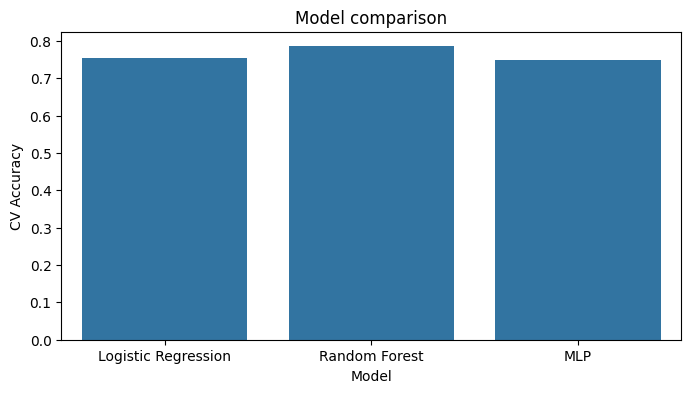

In [133]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x='Model',
    y='CV Accuracy'
)

plt.title('Model comparison')
plt.show()

## 4.7 Hyperparameter tuning

In [107]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

In [108]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [109]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

The best parametres:

In [110]:
print(grid_rf.best_params_)

{'max_depth': None, 'n_estimators': 300}


The best metric:

In [111]:
print(grid_rf.best_score_)

0.7897361500269175


## 4.8 Model selection (choosing the best model)

In [112]:
best_model = grid_rf.best_estimator_
best_model

RandomForestClassifier(n_estimators=300, random_state=42)

## 4.9 Evaluation on the test set

In [113]:
y_pred = best_model.predict(
    X_test
)

Accuracy

In [114]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.8080934501460159


Classification Report

In [115]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        high       0.87      0.87      0.87       807
         low       0.82      0.85      0.83       789
      medium       0.73      0.71      0.72       801

    accuracy                           0.81      2397
   macro avg       0.81      0.81      0.81      2397
weighted avg       0.81      0.81      0.81      2397



Confusion matrix:

In [116]:
cm = confusion_matrix(
    y_test,
    y_pred
)

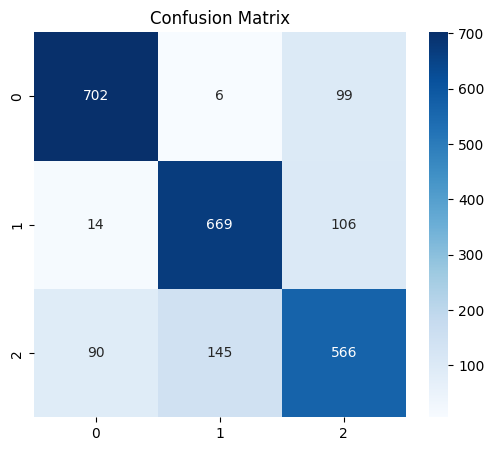

In [117]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

##  4.10 Overfitting check

In [118]:
train_score = best_model.score(
    X_train,
    y_train
)

test_score = best_model.score(
    X_test,
    y_test
)

In [119]:
print(train_score)
print(test_score)

1.0
0.8080934501460159


# Results

## Training the final model on the full dataset

In [120]:
y = df['price_category']

X = df.drop(columns=['price_category', 'price'])

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)


In [121]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ))
])

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'lat', 'long', 'posting_dayofweek', 'car_age'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [122]:
print(X.shape)
print(X.select_dtypes(include='object').columns)

(9588, 17)
Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')


## Pickle

In [123]:
with open('final_model.pkl', 'wb') as file:
  pickle.dump(final_model, file)

Model loading check

In [124]:
with open('final_model.pkl', 'rb') as file:
  loaded_model = pickle.load(file)

In [125]:
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [126]:
loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'lat', 'long', 'posting_dayofweek', 'car_age'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

## Model training and evaluation

In the modeling stage, three classification algorithms were considered: **Logistic Regression**, **Random Forest**, and **Multilayer Perceptron (MLPClassifier)**.

The dataset was split into training and test sets in a **75% / 25%** ratio.

To select the best model, **cross-validation** was performed on the training set. The following accuracy scores were obtained:

* Logistic Regression — **0.755**
* Random Forest — **0.785**
* MLPClassifier — **0.750**

The best performance was achieved by the **Random Forest** model, which was therefore selected for hyperparameter tuning using **GridSearchCV**. The optimal parameters were:

* `n_estimators = 300`
* `max_depth = None`

After training the optimized model, accuracy was evaluated on both training and test sets:

* Training set — **1.00**
* Test set — **0.81**

Despite strong performance on the test set, the perfect training score indicates **overfitting**, meaning the model fits the training data too closely and loses some generalization ability on unseen data.

Overall, the **Random Forest model** was selected as the best-performing model, achieving approximately **81% accuracy** on the test set.
